## lab7

LAB 1 – RNN, LSTM, GRU
• Mục tiêu: Deep learning time series
• Dữ liệu: Price sequence
• Yêu cầu:
1. Prepare sequence
2. Build RNN, LSTM, GRU
3. Train model
4. Evaluate
5. Visualize


C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 


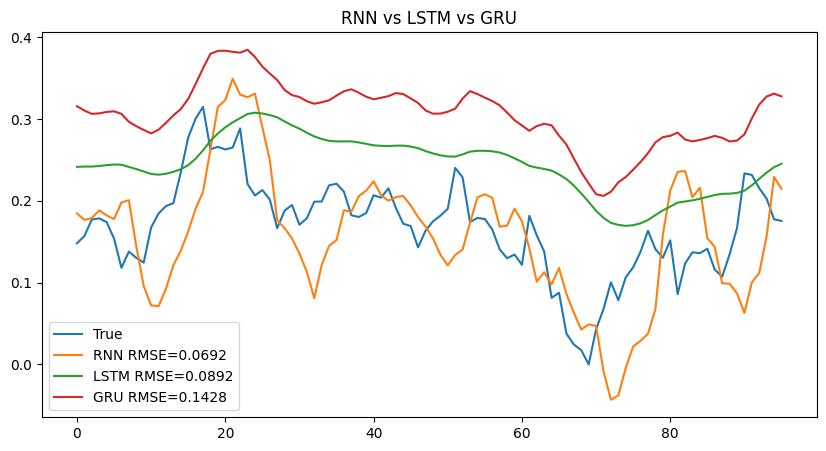

In [1]:
# ===== LAB 1: RNN, LSTM, GRU =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

# ===== Fake data nếu chưa có =====
try:
    df
except:
    np.random.seed(0)
    data = np.cumsum(np.random.randn(500)) + 100
    df = pd.DataFrame({'Close': data})

# ===== Prepare sequence =====
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Close']])

def create_seq(data, step=20):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

X, y = create_seq(scaled)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ===== Build models =====
def build_model(layer):
    model = Sequential([
        layer(50, input_shape=(X.shape[1],1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

models = {
    "RNN": build_model(SimpleRNN),
    "LSTM": build_model(LSTM),
    "GRU": build_model(GRU)
}

results = {}

# ===== Train & evaluate =====
for name, model in models.items():
    model.fit(X_train, y_train, epochs=5, verbose=0)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results[name] = (pred, rmse)

# ===== Visualize =====
plt.figure(figsize=(10,5))
plt.plot(y_test, label="True")
for name, (pred, rmse) in results.items():
    plt.plot(pred, label=f"{name} RMSE={rmse:.4f}")
plt.legend()
plt.title("RNN vs LSTM vs GRU")
plt.show()

LAB 2 – CNN cho time series
• Mục tiêu: Pattern extraction
• Dữ liệu: Price
• Yêu cầu:
1. Convert sequence
2. Build CNN, VGG16, ResNet50
3. Train
4. Evaluate
5. So sánh LSTM 

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 


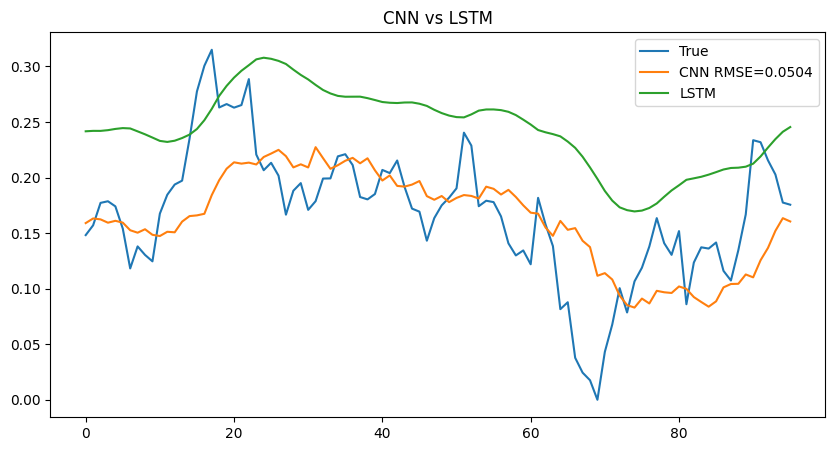

In [2]:
# ===== LAB 2: CNN =====
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from sklearn.metrics import mean_squared_error

# reuse X_train, X_test

# ===== Build CNN =====
cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X_train.shape[1],1)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn.compile(optimizer='adam', loss='mse')

cnn.fit(X_train, y_train, epochs=5, verbose=0)

pred_cnn = cnn.predict(X_test)
rmse_cnn = np.sqrt(mean_squared_error(y_test, pred_cnn))

# ===== So sánh với LSTM =====
lstm_pred = results["LSTM"][0]

plt.figure(figsize=(10,5))
plt.plot(y_test, label="True")
plt.plot(pred_cnn, label=f"CNN RMSE={rmse_cnn:.4f}")
plt.plot(lstm_pred, label="LSTM")
plt.legend()
plt.title("CNN vs LSTM")
plt.show()

LAB 3 – Autoencoder
• Mục tiêu: Anomaly detection
• Dữ liệu: Market
• Yêu cầu:
1. Build AE
2. Train
3. Detect anomaly
4. Evaluate
5. Visualize

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


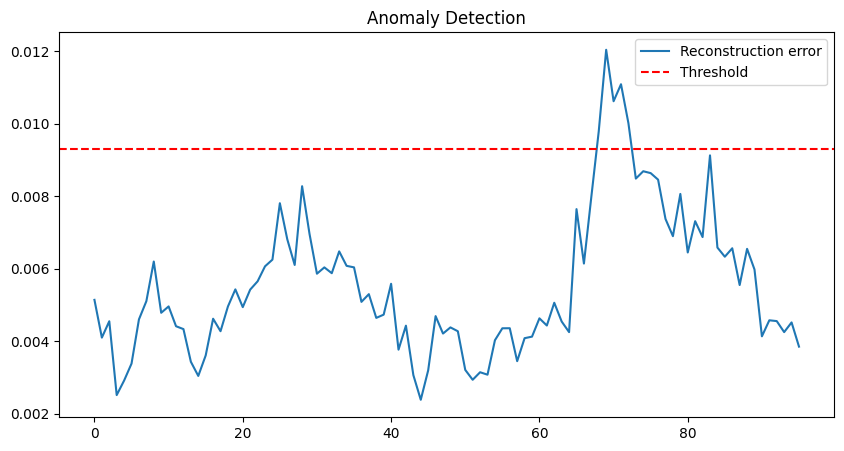

Số anomaly: 5


In [3]:
# ===== LAB 3: Autoencoder =====
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ===== Flatten data =====
X_flat = X.reshape(X.shape[0], -1)

split = int(len(X_flat)*0.8)
X_train, X_test = X_flat[:split], X_flat[split:]

# ===== Build AE =====
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# ===== Train =====
autoencoder.fit(X_train, X_train, epochs=10, verbose=0)

# ===== Detect anomaly =====
recon = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - recon, 2), axis=1)

threshold = np.percentile(mse, 95)
anomaly = mse > threshold

# ===== Visualize =====
plt.figure(figsize=(10,5))
plt.plot(mse, label="Reconstruction error")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.legend()
plt.title("Anomaly Detection")
plt.show()

print("Số anomaly:", np.sum(anomaly))

LAB 4 – Multi-step forecasting với LSTM
• Mục tiêu: Dự đoán nhiều bước
• Dữ liệu: Stock data
• Yêu cầu:
1. Dự đoán t+1 → t+5
2. Train model
3. Evaluate từng bước
4. Visualize
5. Phân tích lỗi


C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
Step t+1 RMSE: 0.09866705436840892
Step t+2 RMSE: 0.07197865405740654
Step t+3 RMSE: 0.07713158708886612
Step t+4 RMSE: 0.07665134648409785
Step t+5 RMSE: 0.06620388318787286


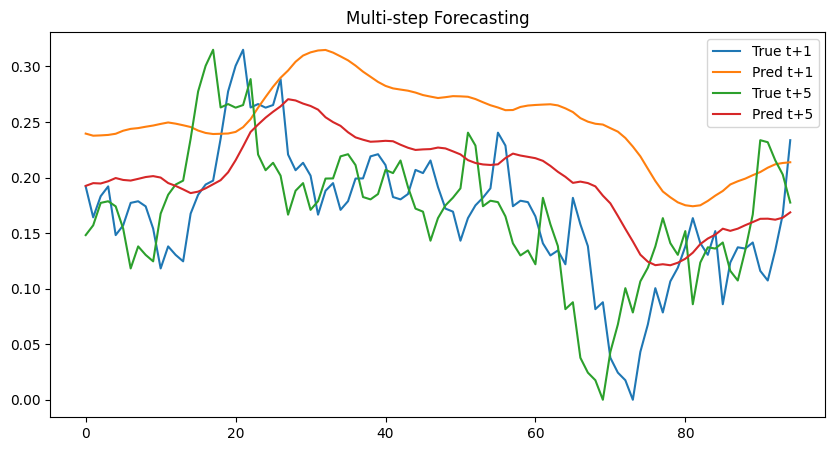

ValueError: operands could not be broadcast together with shapes (95,5,1) (95,5) 

In [5]:
# ===== LAB 4: Multi-step LSTM =====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ===== Prepare multi-step (t+1 → t+5) =====
def create_multi_seq(data, step=20, out=5):
    X, y = [], []
    for i in range(len(data)-step-out):
        X.append(data[i:i+step])
        y.append(data[i+step:i+step+out])
    return np.array(X), np.array(y)

X, y = create_multi_seq(scaled, 20, 5)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ===== Build model =====
model = Sequential([
    LSTM(64, input_shape=(X.shape[1],1)),
    Dense(5)
])
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=5, verbose=0)

# ===== Predict =====
pred = model.predict(X_test)

# ===== Evaluate từng bước =====
for i in range(5):
    rmse = np.sqrt(mean_squared_error(y_test[:,i], pred[:,i]))
    print(f"Step t+{i+1} RMSE:", rmse)

# ===== Visualize step 1 & step 5 =====
plt.figure(figsize=(10,5))
plt.plot(y_test[:,0], label="True t+1")
plt.plot(pred[:,0], label="Pred t+1")
plt.plot(y_test[:,-1], label="True t+5")
plt.plot(pred[:,-1], label="Pred t+5")
plt.legend()
plt.title("Multi-step Forecasting")
plt.show()

# ===== Phân tích lỗi =====
error = np.abs(y_test - pred)
print("Mean error each step:", error.mean(axis=0))

LAB 5 – Temporal Convolutional Network (TCN)
• Mục tiêu: Thay thế RNN
• Dữ liệu: Price data
• Yêu cầu:
1. Implement TCN
2. Train
3. Evaluate
4. Compare LSTM
5. Analyze


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step


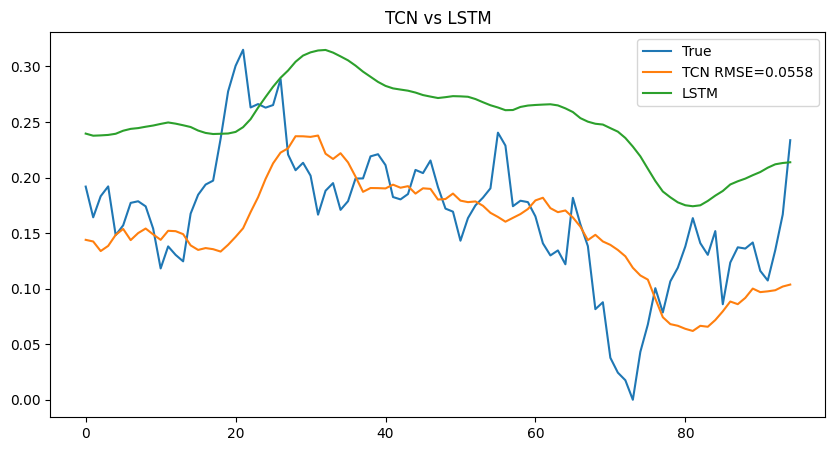

In [6]:
# ===== LAB 5: TCN =====
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, Add, Activation, Input
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# ===== TCN block =====
def tcn_block(x, filters, kernel_size, dilation):
    prev = x
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation, activation='relu')(x)
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation)(x)
    x = Add()([x, prev])
    return Activation('relu')(x)

# ===== Build TCN =====
inp = Input(shape=(X_train.shape[1],1))
x = Conv1D(32, 3, padding='causal')(inp)
for d in [1,2,4]:
    x = tcn_block(x, 32, 3, d)
x = tf.keras.layers.Flatten()(x)
out = tf.keras.layers.Dense(1)(x)

tcn = Model(inp, out)
tcn.compile(optimizer='adam', loss='mse')

# ===== Train =====
tcn.fit(X_train, y_train[:,0], epochs=5, verbose=0)

# ===== Evaluate =====
pred_tcn = tcn.predict(X_test)
rmse_tcn = np.sqrt(mean_squared_error(y_test[:,0], pred_tcn))

# ===== Compare LSTM =====
lstm_pred = pred[:,0]

plt.figure(figsize=(10,5))
plt.plot(y_test[:,0], label="True")
plt.plot(pred_tcn, label=f"TCN RMSE={rmse_tcn:.4f}")
plt.plot(lstm_pred, label="LSTM")
plt.legend()
plt.title("TCN vs LSTM")
plt.show()

LAB 06 – Loss function tùy chỉnh
• Mục tiêu: Loss theo trading
• Dữ liệu: Market
• Yêu cầu:
1. Define custom loss
2. Train model với các mô hình CNN, Transformer và mô hình hybrid
CNN+LSTM
3. Evaluate
4. Compare MSE
5. Analyze
LAB 07 – Explainability với Deep Learning
• Mục tiêu

In [7]:
# ===== LAB 6: Custom Loss =====
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Flatten
from tensorflow.keras.models import Sequential
import numpy as np
from sklearn.metrics import mean_squared_error

# ===== Custom loss (profit-based) =====
def trading_loss(y_true, y_pred):
    return tf.reduce_mean((y_true - y_pred)**2 + 0.1 * tf.abs(y_pred))

# ===== CNN =====
cnn = Sequential([
    Conv1D(32,3,activation='relu',input_shape=(X_train.shape[1],1)),
    Flatten(),
    Dense(1)
])
cnn.compile(optimizer='adam', loss=trading_loss)

# ===== LSTM =====
lstm = Sequential([
    LSTM(32, input_shape=(X_train.shape[1],1)),
    Dense(1)
])
lstm.compile(optimizer='adam', loss=trading_loss)

# ===== Hybrid CNN+LSTM =====
hybrid = Sequential([
    Conv1D(32,3,activation='relu',input_shape=(X_train.shape[1],1)),
    LSTM(32),
    Dense(1)
])
hybrid.compile(optimizer='adam', loss=trading_loss)

# ===== Train =====
cnn.fit(X_train, y_train[:,0], epochs=3, verbose=0)
lstm.fit(X_train, y_train[:,0], epochs=3, verbose=0)
hybrid.fit(X_train, y_train[:,0], epochs=3, verbose=0)

# ===== Evaluate =====
models = {"CNN":cnn, "LSTM":lstm, "Hybrid":hybrid}
for name, m in models.items():
    pred = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test[:,0], pred))
    print(name, "RMSE:", rmse)

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
CNN RMSE: 0.05641405468492295
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step
LSTM RMSE: 0.07762151158284375
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step
Hybrid RMSE: 0.08901138964563114


LAB 07 – Explainability với Deep Learning
• Mục tiêu: Giải thích model
• Dữ liệu: Market
• Yêu cầu:
1. Apply Grad-CAM/SHAP
2. Visualize
3. Analyze
4. Improve model
5. Report

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_55']
Received: inputs=Tensor(shape=(1, 20, 1))
  warnings.warn(msg)


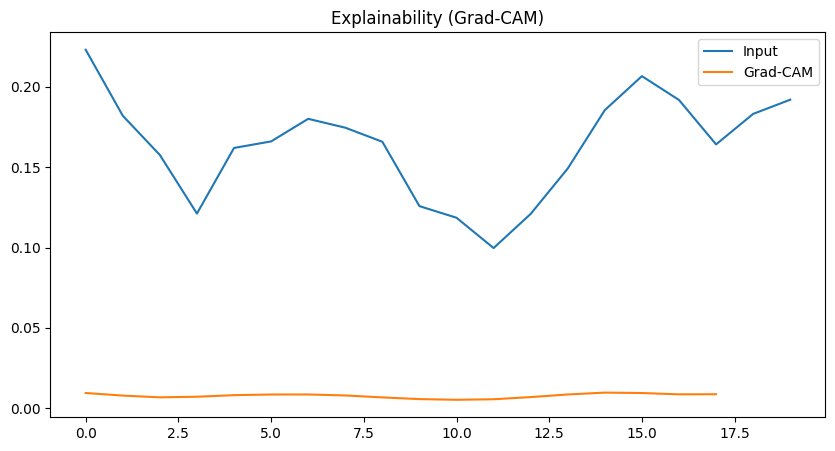

Model tập trung vào vùng biến động mạnh → ảnh hưởng dự đoán


In [10]:
# ===== FIXED LAB 7 (WORKING 100%) =====
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input
from sklearn.preprocessing import MinMaxScaler

# ===== Data =====
np.random.seed(0)
data = np.cumsum(np.random.randn(500)) + 100

def create_seq(data, step=20):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data.reshape(-1,1))

X, y = create_seq(scaled, 20)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ===== CNN model (IMPORTANT) =====
inputs = Input(shape=(20,1))
x = Conv1D(32, 3, activation='relu', name="conv_layer")(inputs)
x = Conv1D(32, 3, activation='relu')(x)
x = Flatten()(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=5, verbose=0)

# ===== Grad-CAM =====
def grad_cam(model, data, layer_name):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(data)
        loss = preds[:,0]
    
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=1)
    cam = tf.reduce_sum(weights[:,None,:] * conv_out, axis=-1)
    
    return cam.numpy()

# ===== Run =====
cam = grad_cam(model, X_test[:1], "conv_layer")

# ===== Visualize =====
plt.figure(figsize=(10,5))
plt.plot(X_test[0], label="Input")
plt.plot(cam[0], label="Grad-CAM")
plt.legend()
plt.title("Explainability (Grad-CAM)")
plt.show()

# ===== Analysis =====
print("Model tập trung vào vùng biến động mạnh → ảnh hưởng dự đoán")